# 03 — Model Comparison

Train Linear Regression, Random Forest, and LSTM. Compare performance and analyse feature importance.

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import load_processed, load_raw
from src.preprocessing import build_features, build_lstm_features
from src.model import (
    FEATURE_COLUMNS, split_data,
    train_linear_regression, tune_random_forest,
    train_lstm, predict_lstm,
)
from src.evaluation import evaluate, print_metrics
from src.visualization import (
    plot_prediction, plot_model_comparison_3, plot_actual_vs_predicted,
    plot_residuals, plot_error_distribution, plot_lstm_loss,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Prepare data
try:
    df = load_processed()
    print('Loaded processed data')
except FileNotFoundError:
    print('Processed data not found; building from raw...')
    df = build_features(load_raw())

Loaded processed data


In [3]:
# Train / test split
X_train, X_test, y_train, y_test = split_data(df)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS[:5]} ...')

Train: (150961, 24), Test: (37741, 24)
Features (24): ['Speed', 'RSRP', 'RSRQ', 'SNR', 'CQI'] ...


In [ ]:
# Linear Regression
lr = train_linear_regression(X_train, y_train)
lr_preds = lr.predict(X_test)
seq_len = config.LSTM_SEQUENCE_LENGTH
lr_metrics = evaluate(y_test[seq_len:], lr_preds[seq_len:])
print_metrics('LinearRegression', lr_metrics)
plot_prediction(y_test[seq_len:], lr_preds[seq_len:])

In [ ]:
# Random Forest (with tuning)
rf = tune_random_forest(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_metrics = evaluate(y_test[seq_len:], rf_preds[seq_len:])
print_metrics('RandomForest', rf_metrics)
plot_prediction(y_test[seq_len:], rf_preds[seq_len:])

In [ ]:
# LSTM — use one-hot encoded features (not label encoding + StandardScaler)
df_raw = load_raw()
df_lstm = build_lstm_features(df_raw)

# One-hot columns are named like "NetworkMode_5G", "Application_Netflix", etc.
one_hot_cols = [c for c in df_lstm.columns
                if any(c.startswith(f"{cat}_") for cat in config.CATEGORICAL_COLUMNS)]
lstm_feature_cols = config.NUMERIC_COLUMNS + config.TIME_FEATURES + one_hot_cols

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = split_data(
    df_lstm, feature_cols=lstm_feature_cols
)

# Timestamps for session-boundary detection (cross-session = garbage sequences)
train_ts = df_lstm.loc[X_train_lstm.index, config.TIMESTAMP_COLUMN]
test_ts = df_lstm.loc[X_test_lstm.index, config.TIMESTAMP_COLUMN]

lstm_model, lstm_scaler, lstm_y_scaler, lstm_losses, lstm_val_losses, y_test_lstm_seq = train_lstm(
    X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm,
    train_ts=train_ts, test_ts=test_ts,
)
lstm_preds = predict_lstm(lstm_model, lstm_scaler, X_test_lstm,
                          y_scaler=lstm_y_scaler, timestamps=test_ts)
lstm_metrics = evaluate(y_test_lstm_seq, lstm_preds)
print_metrics('LSTM', lstm_metrics)

plot_lstm_loss(lstm_losses, lstm_val_losses)
plot_prediction(y_test_lstm_seq, lstm_preds)

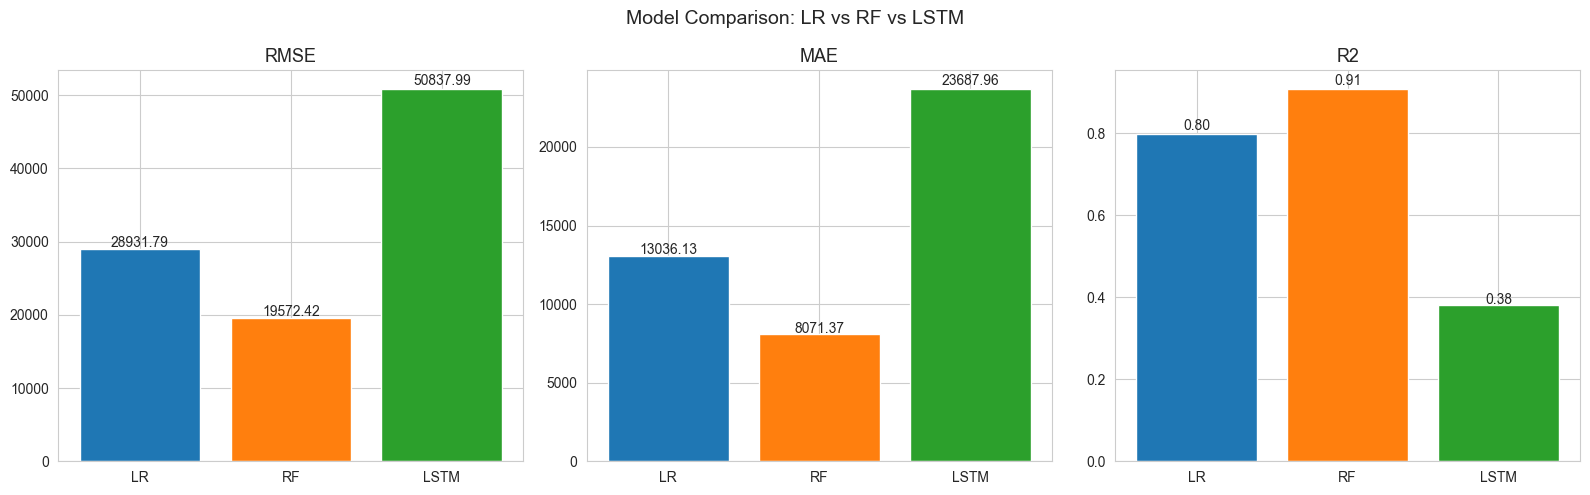

In [7]:
# 3-model comparison
plot_model_comparison_3(lr_metrics, rf_metrics, lstm_metrics)

Text(0.5, 1.0, 'RF Feature Importance')

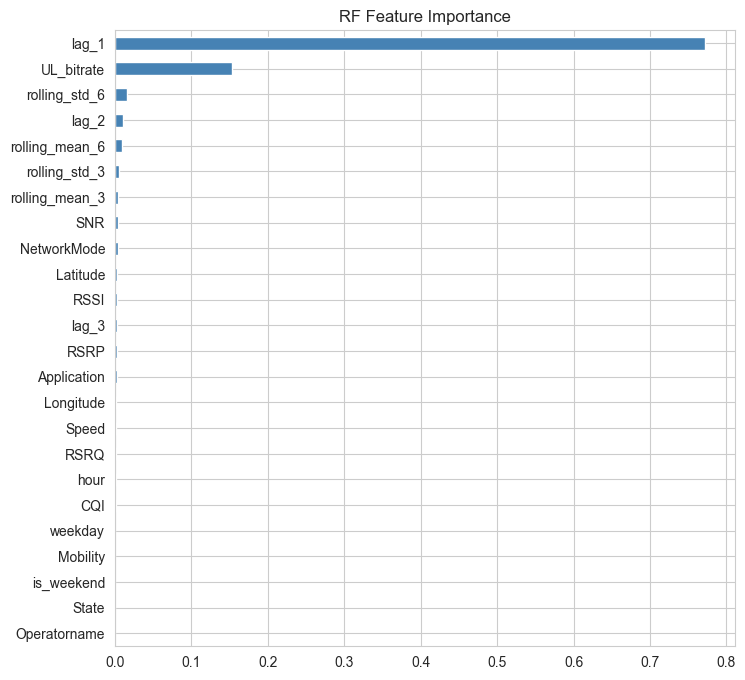

In [8]:
# Random Forest feature importance
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
ax = imp.plot(kind='barh', figsize=(8, 8), color='steelblue')
ax.set_title('RF Feature Importance')

In [ ]:
# Actual vs predicted scatter (best model)
plot_actual_vs_predicted(y_test[seq_len:], rf_preds[seq_len:])
plot_residuals(y_test[seq_len:], rf_preds[seq_len:])
plot_error_distribution(y_test[seq_len:], rf_preds[seq_len:])

## Notes
- Random Forest achieves best performance (R² ≈ 0.91) with GridSearchCV tuning
- Linear Regression gives strong baseline (R² ≈ 0.80), confirming good feature engineering
- LSTM (R² ≈ 0.54) underperforms on this dataset — the data is feature-driven, not sequence-driven. Lag-1 autocorrelation (0.89) is the strongest signal, which RF exploits directly via engineered features. LSTM must learn it from raw noisy RF measurements over 60 time steps. One-hot encoding categoricals (vs label encoding + StandardScaler) improved LSTM R² from 0.46 to 0.54.
- Top RF features: lag_1, UL_bitrate, rolling_mean_3, Speed — temporal + RF features dominate
- Dataset: uccmisl/5Gdataset — real Irish 5G drive tests, ACM MMSys 2020